In [ ]:
## Dataset Information

The Iris dataset is a well-known dataset used for classification problems.

It contains 150 samples and 4 numerical features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The dataset contains three Iris flower species:

- Setosa
- Versicolor
- Virginica

The dataset is loaded directly from `scikit-learn`.

# Iris Flower Classification

## OASIS INFOBYTE — Data Science Internship

**Task:** Task 1 – Iris Flower Classification  
**Intern:** Subhankar Ranasingh

### Objective
To build a machine learning classification model that can classify Iris flowers into different species using their flower measurements.

In [23]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
# Load the Iris dataset

iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [3]:
# Convert the Iris dataset into a DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target/species column
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Display the shape of the dataset

print("Number of rows and columns:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display data types
print("\nData types:")
print(df.dtypes)

Number of rows and columns: (150, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object


In [5]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [6]:
# Display descriptive statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# Count the number of samples for each species

print(df["species"].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


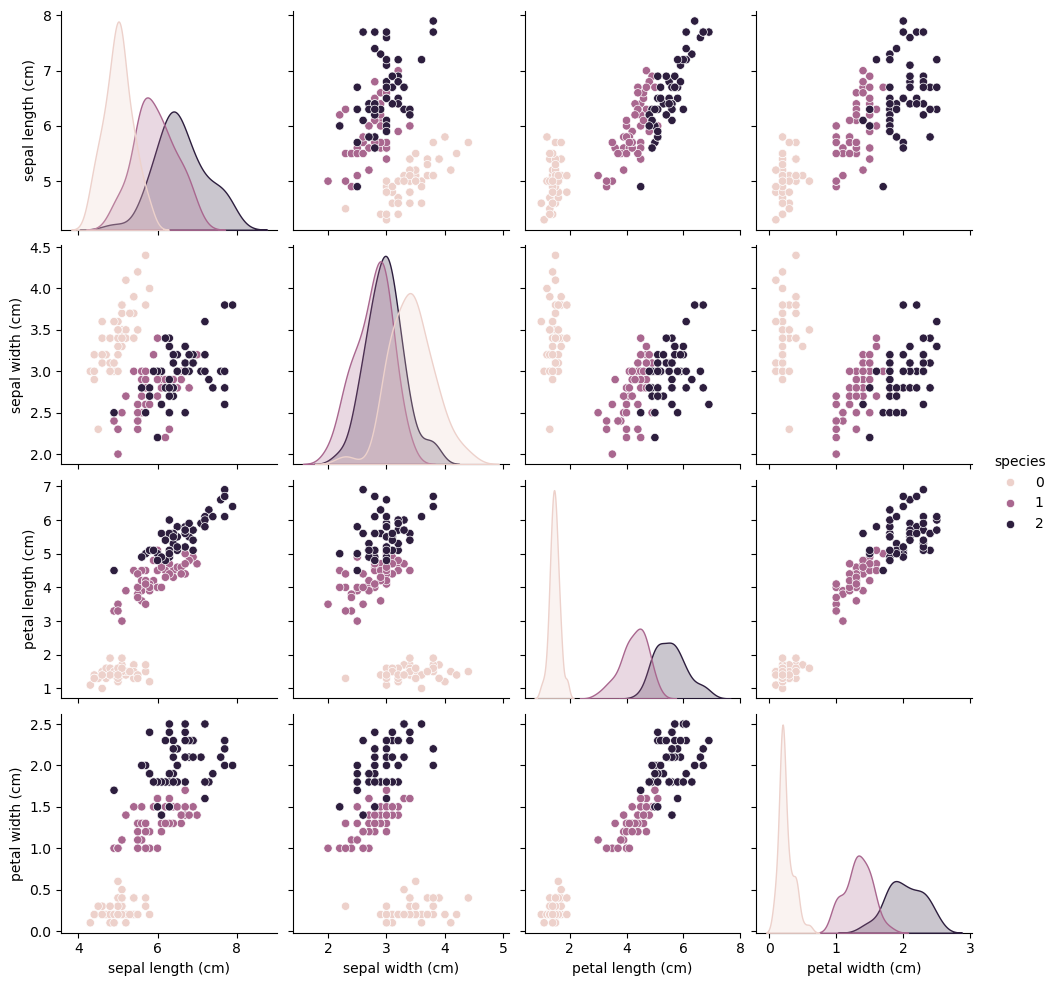

In [8]:
# Pairplot to visualize relationships between features

sns.pairplot(df, hue="species")
plt.show()

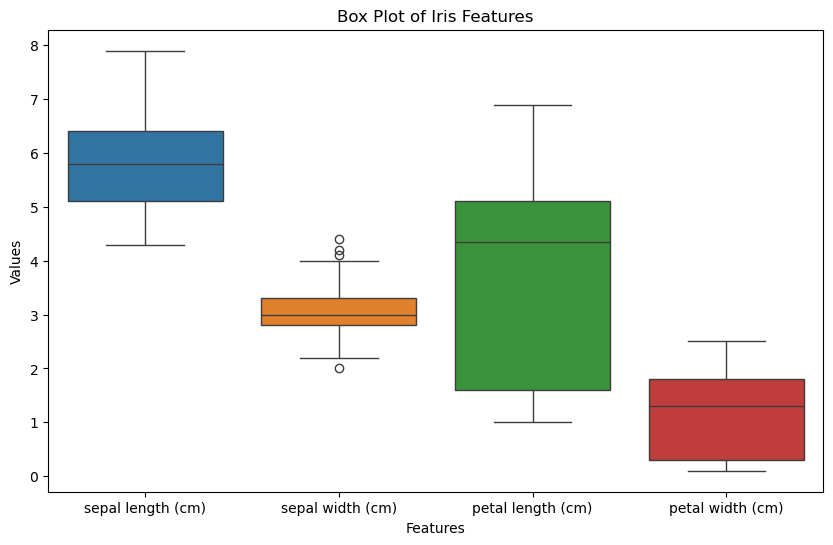

In [9]:
# Box plots for all numerical features

plt.figure(figsize=(10, 6))

sns.boxplot(data=df.drop(columns="species"))

plt.title("Box Plot of Iris Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [10]:
# Check correlation between numerical features

correlation = df.drop(columns="species").corr()

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


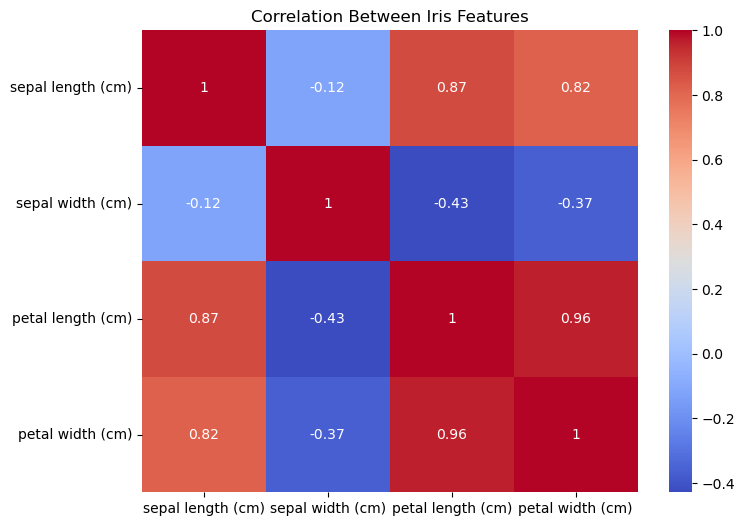

In [11]:
# Visualize feature correlation using heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Iris Features")
plt.show()

## Feature Selection and Discriminative Features

The Iris dataset contains four numerical features: sepal length, sepal width, petal length, and petal width.

From the visualizations and correlation analysis, petal length and petal width show good separation between the different Iris species.

Therefore, petal length and petal width are considered highly discriminative features for Iris flower classification. However, all four features are used in the machine learning models to provide complete information to the classifiers.

In [12]:
# Separate features and target

X = df.drop(columns="species")
y = df["species"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [14]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model_lr = LogisticRegression(max_iter=200)

# Train the model
model_lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
model_knn.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [16]:
# Make predictions using both models

y_pred_lr = model_lr.predict(X_test)
y_pred_knn = model_knn.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [17]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for both models
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Logistic Regression Accuracy:", accuracy_lr)
print("KNN Accuracy:", accuracy_knn)

Logistic Regression Accuracy: 0.9666666666666667
KNN Accuracy: 1.0


In [18]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix - Logistic Regression")
print(cm_lr)

# Confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nConfusion Matrix - KNN")
print(cm_knn)

Confusion Matrix - Logistic Regression
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Confusion Matrix - KNN
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


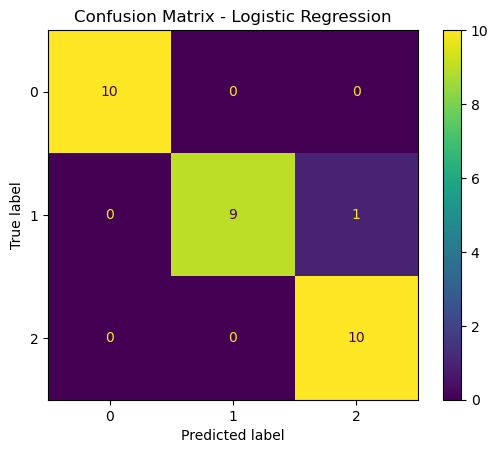

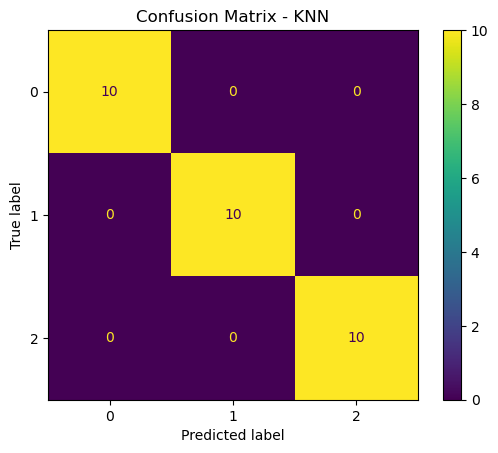

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix - Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Confusion Matrix - KNN
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("Confusion Matrix - KNN")
plt.show()

In [20]:
from sklearn.metrics import classification_report

# Classification report for Logistic Regression
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))

# Classification report for KNN
print("Classification Report - KNN")
print(classification_report(y_test, y_pred_knn))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Classification Report - KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
# Compare model accuracies

print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")
print(f"KNN Accuracy: {accuracy_knn * 100:.2f}%")

if accuracy_knn > accuracy_lr:
    print("\nBest Model: KNN")
    print("KNN achieved higher accuracy on the test dataset.")
elif accuracy_lr > accuracy_knn:
    print("\nBest Model: Logistic Regression")
    print("Logistic Regression achieved higher accuracy on the test dataset.")
else:
    print("\nBoth models have the same accuracy.")

Logistic Regression Accuracy: 96.67%
KNN Accuracy: 100.00%

Best Model: KNN
KNN achieved higher accuracy on the test dataset.


In [22]:
# Final Conclusion

print("Conclusion:")
print("The Iris Flower Classification project was successfully completed.")
print(f"Logistic Regression achieved {accuracy_lr * 100:.2f}% accuracy.")
print(f"KNN achieved {accuracy_knn * 100:.2f}% accuracy.")
print("Based on the test results, KNN performed better than Logistic Regression.")
print("Therefore, KNN is selected as the best-performing model for this dataset.")

Conclusion:
The Iris Flower Classification project was successfully completed.
Logistic Regression achieved 96.67% accuracy.
KNN achieved 100.00% accuracy.
Based on the test results, KNN performed better than Logistic Regression.
Therefore, KNN is selected as the best-performing model for this dataset.
